In [4]:
import yfinance as yf 
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt


In [40]:
df = yf.download('SPY', start="1996-01-01", end="2025-12-31")

[*********************100%***********************]  1 of 1 completed


In [41]:
df

Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
1996-01-02,36.813374,36.813374,36.341289,36.378315,514400
1996-01-03,36.915184,37.026263,36.730053,36.933697,610300
1996-01-04,36.563457,37.100339,36.267247,36.961490,1129700
1996-01-05,36.489384,36.581949,36.239456,36.322766,302400
1996-01-08,36.628242,36.674525,36.572703,36.618986,179900
...,...,...,...,...,...
2025-12-23,686.086304,686.325640,682.007416,682.057268,64840000
2025-12-24,688.499695,688.948481,685.926705,686.076320,39445600


In [42]:
print(df.columns)

MultiIndex([( 'Close', 'SPY'),
            (  'High', 'SPY'),
            (   'Low', 'SPY'),
            (  'Open', 'SPY'),
            ('Volume', 'SPY')],
           names=['Price', 'Ticker'])


In [43]:
df['Close']['SPY']

Date
1996-01-02     36.813374
1996-01-03     36.915184
1996-01-04     36.563457
1996-01-05     36.489384
1996-01-08     36.628242
                 ...    
2025-12-23    686.086304
2025-12-24    688.499695
2025-12-26    688.429871
2025-12-29    685.976562
2025-12-30    685.138916
Name: SPY, Length: 7549, dtype: float64

In [44]:
spy = df['Close'].squeeze()

<Axes: xlabel='Date'>

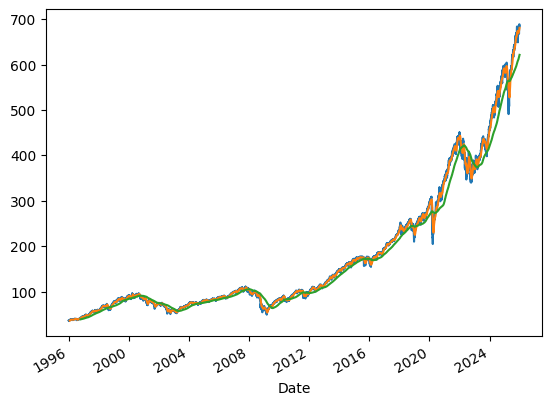

In [45]:
spy.plot()
ma1 = spy.rolling(20).mean()
ma2 = spy.rolling(200).mean()
ma1.plot()
ma2.plot()

In [78]:
pnls = []
entry = None
dates = []
inpos = 0
unrlzd = []
unrlzd_dt = []
comm = 0.001 # commission
hold_times = []

for i in range (1, len(spy)):
    unr = (spy.iloc[i] - spy.iloc[i-1]) * inpos / spy.iloc[i-1]
    unrlzd.append(unr)
    unrlzd_dt.append(spy.index[i])

    if ma1.iloc[i]>ma2.iloc[i] and ma1.iloc[i-1]<ma2.iloc[i-1]:
        # if entry:
        #     pnl = (entry - spy.iloc[i]) / entry
        #     pnls.append(pnl)
        #     dates.append(spy.index[i])
        entry  = spy.iloc[i]
        inpos = 1
        unrlzd[-1] -= comm
        hold_times.append((spy.index[i] - start).days)

    elif ma1.iloc[i]<ma2.iloc[i] and ma1.iloc[i-1]>ma2.iloc[i-1]:
        if entry:
            pnl = (spy.iloc[i] - entry) / entry - 0.002
            pnls.append(pnl)
            dates.append(spy.index[i])
        entry = spy.iloc[i]
        inpos = 0
        unrlzd[-1] -= comm
        start = spy.index[i]



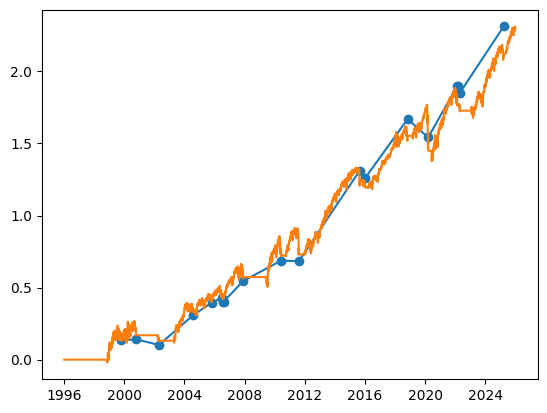

In [79]:
plt.plot(dates, np.cumsum(np.array(pnls)),'-o' )
plt.plot(unrlzd_dt, np.cumsum(unrlzd))

In [80]:
np.mean(unrlzd) / np.std(unrlzd) * 16

np.float64(0.63649772989406)

In [84]:
ppt = np.mean(pnls)
ppt

np.float64(0.1155696121687497)

In [85]:
np.mean(hold_times)

np.float64(123.33333333333333)